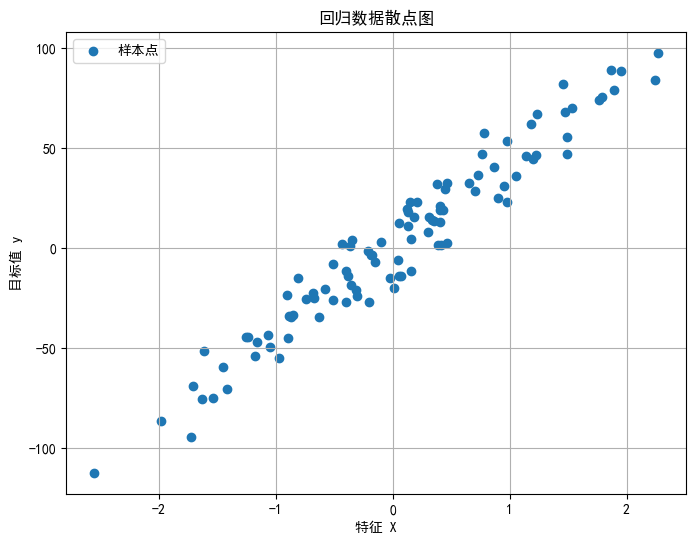

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 设置中文字体和负号正常显示
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False

# 生成数据: 100个样本, 1个特征, 噪声为10, 偏置为1.5, 返回真实系数
X, y, coef = make_regression(n_samples=100, n_features=1, noise=10, bias=1.5, coef=True, random_state=0)

# 可视化回归数据散点图
plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='tab:blue', label='样本点')
plt.xlabel('特征 X')
plt.ylabel('目标值 y')
plt.title('回归数据散点图')
plt.legend()
plt.grid(True)
plt.show()

学习到的参数: w = 40.0583, b = 1.1880


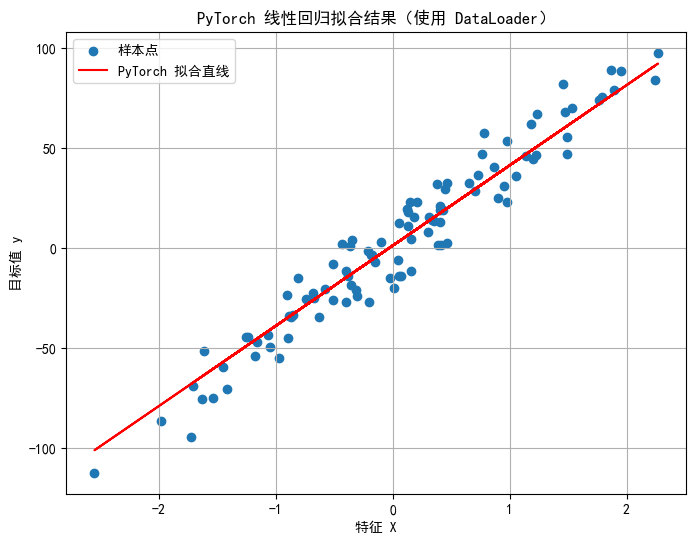

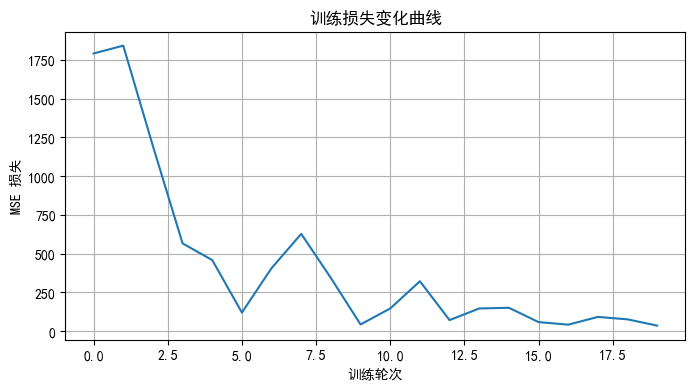

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. 准备数据（构造 Dataset 和 DataLoader）
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float().view(-1, 1)

dataset = TensorDataset(X_tensor, y_tensor)
# DataLoader 用于批量读取数据，batch_size=16 表示每个批次包含16个样本，shuffle=True 表示每个epoch开始前都会打乱数据
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# 2. 构建模型
torch.manual_seed(0)  # 设置随机种子，确保结果可复现
model = nn.Linear(in_features=1, out_features=1)  # 定义线性回归模型，输入特征数为1，输出特征数为1

# 3. 定义损失函数与优化器
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 使用随机梯度下降优化器，学习率为0.01

# 4. 模型训练
num_epochs = 20  # 训练轮次
    # 调整发现约20轮训练模型已达最佳拟合效果

loss_history = []  # 存储每个epoch的损失值

for epoch in range(num_epochs):
    for batch_X, batch_y in dataloader:
        # 前向传播
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_history.append(loss.item())

# 打印学习到的参数
w = model.weight.item()
b = model.bias.item()
print(f"学习到的参数: w = {w:.4f}, b = {b:.4f}")

# 绘制拟合直线
with torch.no_grad():
    y_fit = model(X_tensor).numpy()

plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='tab:blue', label='样本点')
plt.plot(X, y_fit, color='red', label='PyTorch 拟合直线')
plt.xlabel('特征 X')
plt.ylabel('目标值 y')
plt.title('PyTorch 线性回归拟合结果（使用 DataLoader）')
plt.legend()
plt.grid(True)
plt.show()

# 绘制损失下降曲线
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('训练轮次')
plt.ylabel('MSE 损失')
plt.title('训练损失变化曲线')
plt.grid(True)
plt.show()
